# 04 — Entrenamiento de Modelos: Random Forest y XGBoost
**Sistema de Predicción de Enfermedades Cardiovasculares**
Sebastián Torres · Mayerlis Acosta Peralta · Christian Rivera

---
Este notebook entrena y compara Random Forest y XGBoost sobre `cardio_features.csv`. Se ajustan hiperparámetros con búsqueda en grilla, se evalúan con accuracy, F1 y AUC-ROC, se selecciona el mejor modelo y se serializa como `.pkl` listo para el backend.

## 1. Configuración del entorno
Montamos Drive, importamos librerías y definimos rutas. La carpeta `models/` en Drive almacenará los `.pkl` que luego se copian al proyecto en VSCode.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, roc_curve, confusion_matrix)
from xgboost import XGBClassifier

FEATURES_PATH = '/content/drive/MyDrive/cardio-backend/data/processed/cardio_features.csv'
MODEL_RF_PATH  = '/content/drive/MyDrive/cardio-backend/models/random_forest.pkl'
MODEL_XGB_PATH = '/content/drive/MyDrive/cardio-backend/models/xgboost_model.pkl'

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
print('✓ Entorno listo')

Mounted at /content/drive
✓ Entorno listo


## 2. Carga del dataset y división train/test
Separamos el 80% para entrenamiento y el 20% para evaluación final. Usamos `stratify=y` para que ambos conjuntos mantengan el mismo balance de clases (50/50).

In [3]:
df = pd.read_csv(FEATURES_PATH)
print(f'Registros: {len(df):,}   |   Columnas: {df.shape[1]}')

FEATURES = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi',
            'age_range', 'bp_category', 'pulse_pressure', 'metabolic_risk']

X = df[FEATURES]
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {len(X_train):,} registros')
print(f'Test:  {len(X_test):,} registros')
print(f'Balance train — 0: {(y_train==0).sum():,}  1: {(y_train==1).sum():,}')
print(f'Balance test  — 0: {(y_test==0).sum():,}  1: {(y_test==1).sum():,}')

Registros: 68,515   |   Columnas: 17

Train: 54,812 registros
Test:  13,703 registros
Balance train — 0: 27,693  1: 27,119
Balance test  — 0: 6,923  1: 6,780


## 3. Baseline con parámetros por defecto
Antes del tuning entrenamos ambos modelos con parámetros por defecto para tener un punto de referencia. Esto muestra cuánto mejora el ajuste de hiperparámetros.

In [4]:
# Random Forest baseline
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
y_pred_rf  = rf_base.predict(X_test)
y_proba_rf = rf_base.predict_proba(X_test)[:, 1]

print('=== Random Forest — baseline ===')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  F1:       {f1_score(y_test, y_pred_rf):.4f}')
print(f'  AUC-ROC:  {roc_auc_score(y_test, y_proba_rf):.4f}')

# XGBoost baseline
xgb_base = XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric='logloss', verbosity=0)
xgb_base.fit(X_train, y_train)
y_pred_xgb  = xgb_base.predict(X_test)
y_proba_xgb = xgb_base.predict_proba(X_test)[:, 1]

print()
print('=== XGBoost — baseline ===')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'  F1:       {f1_score(y_test, y_pred_xgb):.4f}')
print(f'  AUC-ROC:  {roc_auc_score(y_test, y_proba_xgb):.4f}')

=== Random Forest — baseline ===
  Accuracy: 0.7107
  F1:       0.7032
  AUC-ROC:  0.7660

=== XGBoost — baseline ===
  Accuracy: 0.7295
  F1:       0.7153
  AUC-ROC:  0.7928


## 4. Ajuste de hiperparámetros — Random Forest
Usamos GridSearchCV con validación cruzada estratificada de 5 folds. La métrica de selección es AUC-ROC porque es más informativa que accuracy en problemas de clasificación binaria médica.

La grilla explora profundidad del árbol, número de estimadores y mínimo de muestras por hoja — los hiperparámetros con mayor impacto en Random Forest.

In [5]:
param_grid_rf = {
    'n_estimators':      [100, 200],
    'max_depth':         [6, 10, None],
    'min_samples_leaf':  [1, 4],
    'max_features':      ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

print(f'\nMejores parámetros RF: {grid_rf.best_params_}')
print(f'Mejor AUC-ROC en CV:   {grid_rf.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Mejores parámetros RF: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 200}
Mejor AUC-ROC en CV:   0.8005


In [6]:
# Evaluar el mejor Random Forest en el test set
rf_best = grid_rf.best_estimator_
y_pred_rf  = rf_best.predict(X_test)
y_proba_rf = rf_best.predict_proba(X_test)[:, 1]

print('=== Random Forest — tras tuning ===')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  F1:       {f1_score(y_test, y_pred_rf):.4f}')
print(f'  AUC-ROC:  {roc_auc_score(y_test, y_proba_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Sin cardio', 'Con cardio']))

=== Random Forest — tras tuning ===
  Accuracy: 0.7313
  F1:       0.7149
  AUC-ROC:  0.7979

              precision    recall  f1-score   support

  Sin cardio       0.71      0.78      0.75      6923
  Con cardio       0.75      0.68      0.71      6780

    accuracy                           0.73     13703
   macro avg       0.73      0.73      0.73     13703
weighted avg       0.73      0.73      0.73     13703



## 5. Ajuste de hiperparámetros — XGBoost
La grilla de XGBoost explora la tasa de aprendizaje, profundidad, submuestra de filas y columnas. Estos cuatro parámetros controlan la velocidad de aprendizaje y la regularización implícita del modelo.

In [7]:
param_grid_xgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid_xgb,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

print(f'\nMejores parámetros XGB: {grid_xgb.best_params_}')
print(f'Mejor AUC-ROC en CV:    {grid_xgb.best_score_:.4f}')

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Mejores parámetros XGB: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Mejor AUC-ROC en CV:    0.8019


In [8]:
# Evaluar el mejor XGBoost en el test set
xgb_best = grid_xgb.best_estimator_
y_pred_xgb  = xgb_best.predict(X_test)
y_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]

print('=== XGBoost — tras tuning ===')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'  F1:       {f1_score(y_test, y_pred_xgb):.4f}')
print(f'  AUC-ROC:  {roc_auc_score(y_test, y_proba_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Sin cardio', 'Con cardio']))

=== XGBoost — tras tuning ===
  Accuracy: 0.7331
  F1:       0.7188
  AUC-ROC:  0.7992

              precision    recall  f1-score   support

  Sin cardio       0.72      0.78      0.75      6923
  Con cardio       0.75      0.69      0.72      6780

    accuracy                           0.73     13703
   macro avg       0.73      0.73      0.73     13703
weighted avg       0.73      0.73      0.73     13703



## 6. Comparación de modelos
Tabla y gráficos lado a lado: métricas numéricas, curvas ROC y matrices de confusión. La selección del modelo ganador se hace en la sección siguiente.

In [9]:
# Tabla comparativa
resultados = pd.DataFrame({
    'Modelo':   ['RF baseline', 'RF tuned', 'XGB baseline', 'XGB tuned'],
    'Accuracy': [
        accuracy_score(y_test, rf_base.predict(X_test)),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, xgb_base.predict(X_test)),
        accuracy_score(y_test, y_pred_xgb),
    ],
    'F1': [
        f1_score(y_test, rf_base.predict(X_test)),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, xgb_base.predict(X_test)),
        f1_score(y_test, y_pred_xgb),
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, rf_base.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, xgb_base.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_proba_xgb),
    ],
}).round(4)

print(resultados.to_string(index=False))

      Modelo  Accuracy     F1  AUC-ROC
 RF baseline    0.7107 0.7032   0.7660
    RF tuned    0.7313 0.7149   0.7979
XGB baseline    0.7295 0.7153   0.7928
   XGB tuned    0.7331 0.7188   0.7992


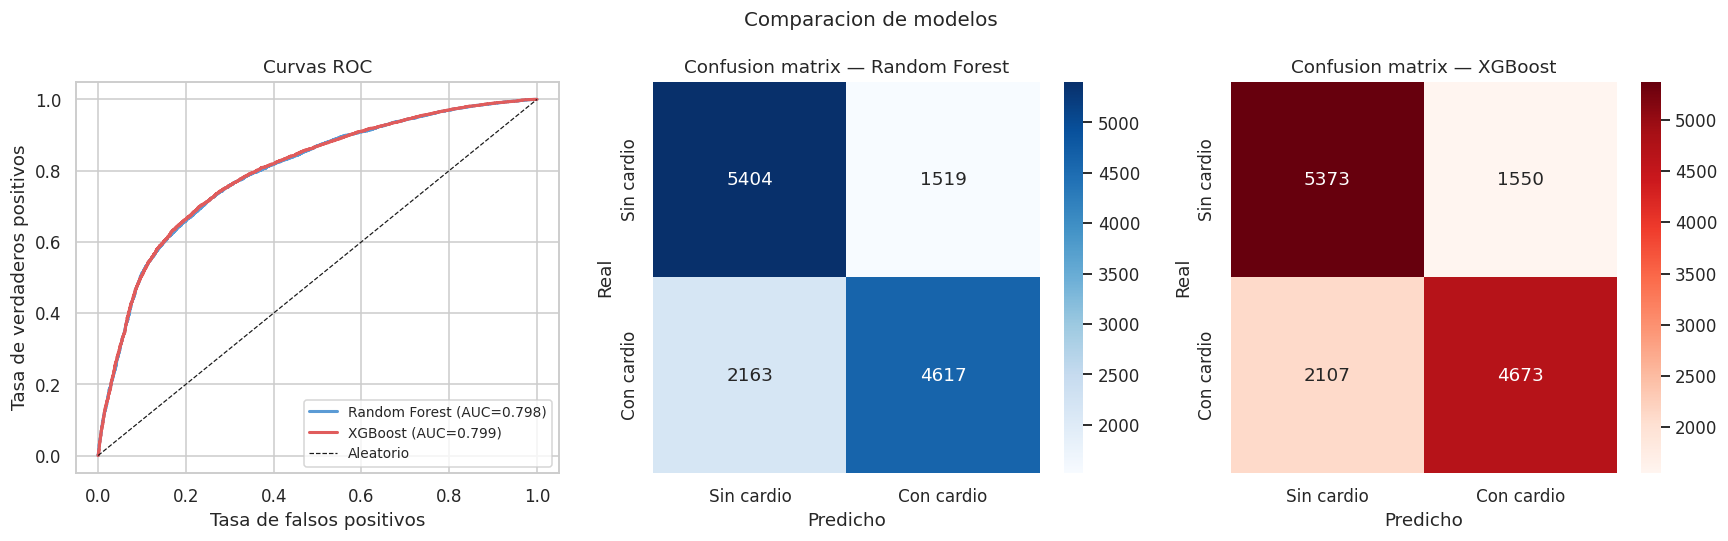

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Curvas ROC
for nombre, y_proba, color in [
    ('Random Forest', y_proba_rf, '#5b9bd5'),
    ('XGBoost', y_proba_xgb, '#e05c5c'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})', color=color, linewidth=2)

axes[0].plot([0,1],[0,1], 'k--', linewidth=0.8, label='Aleatorio')
axes[0].set_xlabel('Tasa de falsos positivos')
axes[0].set_ylabel('Tasa de verdaderos positivos')
axes[0].set_title('Curvas ROC')
axes[0].legend(fontsize=9)

# Matriz de confusión RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Sin cardio','Con cardio'],
            yticklabels=['Sin cardio','Con cardio'])
axes[1].set_title('Confusion matrix — Random Forest')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

# Matriz de confusión XGB
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['Sin cardio','Con cardio'],
            yticklabels=['Sin cardio','Con cardio'])
axes[2].set_title('Confusion matrix — XGBoost')
axes[2].set_ylabel('Real')
axes[2].set_xlabel('Predicho')

plt.suptitle('Comparacion de modelos', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Importancia de features
Ambos modelos rankean las variables por su contribución a las predicciones. Esto es una primera vista de explicabilidad global — la explicabilidad por predicción individual (SHAP/LIME) se implementa en el backend.

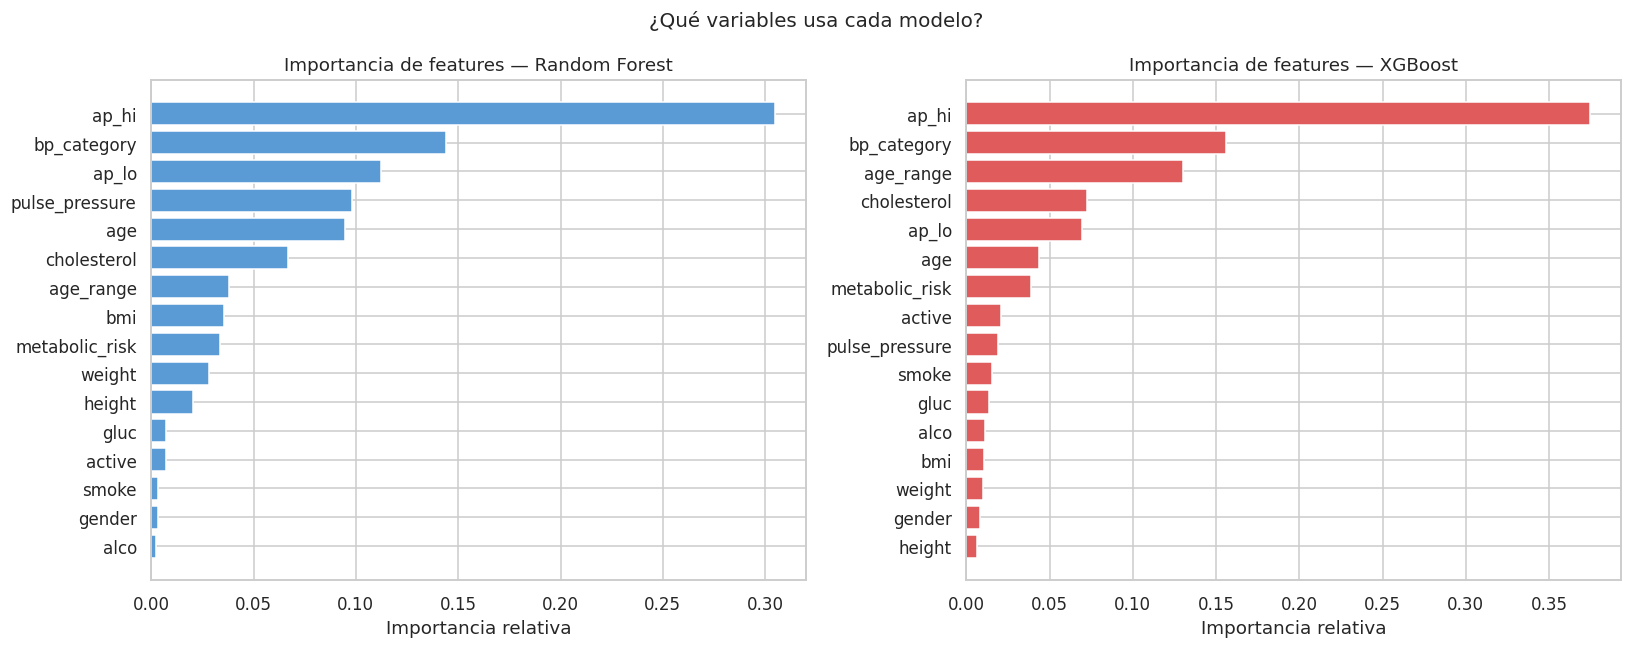

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, modelo, nombre, color in [
    (axes[0], rf_best,  'Random Forest', '#5b9bd5'),
    (axes[1], xgb_best, 'XGBoost',       '#e05c5c'),
]:
    importancias = pd.Series(modelo.feature_importances_, index=FEATURES).sort_values()
    ax.barh(importancias.index, importancias.values, color=color, edgecolor='white')
    ax.set_title(f'Importancia de features — {nombre}')
    ax.set_xlabel('Importancia relativa')

plt.suptitle('¿Qué variables usa cada modelo?', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Selección del mejor modelo
Comparamos AUC-ROC, F1 y accuracy de los dos modelos tuneados. El criterio principal es AUC-ROC porque en un contexto médico importa tanto minimizar falsos negativos (pacientes enfermos no detectados) como falsos positivos (pacientes sanos alarmados innecesariamente).

In [12]:
auc_rf  = roc_auc_score(y_test, y_proba_rf)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print('=== Decisión de selección ===')
print(f'  AUC-ROC Random Forest: {auc_rf:.4f}')
print(f'  AUC-ROC XGBoost:       {auc_xgb:.4f}')
print()

if auc_xgb > auc_rf:
    mejor_modelo  = xgb_best
    nombre_mejor  = 'xgboost'
    print('Modelo seleccionado: XGBoost')
else:
    mejor_modelo  = rf_best
    nombre_mejor  = 'random_forest'
    print('Modelo seleccionado: Random Forest')

print()
print(f'  Accuracy: {accuracy_score(y_test, mejor_modelo.predict(X_test)):.4f}')
print(f'  F1:       {f1_score(y_test, mejor_modelo.predict(X_test)):.4f}')
print(f'  AUC-ROC:  {max(auc_rf, auc_xgb):.4f}')

=== Decisión de selección ===
  AUC-ROC Random Forest: 0.7979
  AUC-ROC XGBoost:       0.7992

Modelo seleccionado: XGBoost

  Accuracy: 0.7331
  F1:       0.7188
  AUC-ROC:  0.7992


## 9. Serialización de modelos
Guardamos ambos modelos en Drive con joblib. El backend carga el modelo activo según la variable `BEST_MODEL` en el archivo `.env` del proyecto.

In [13]:
joblib.dump(rf_best,  MODEL_RF_PATH)
joblib.dump(xgb_best, MODEL_XGB_PATH)

print(f'✓ Random Forest guardado en:  {MODEL_RF_PATH}')
print(f'✓ XGBoost guardado en:        {MODEL_XGB_PATH}')
print(f'\nModelo activo para el backend: {nombre_mejor}')
print(f'Configura BEST_MODEL={nombre_mejor} en el archivo .env del proyecto')

✓ Random Forest guardado en:  /content/drive/MyDrive/cardio-backend/models/random_forest.pkl
✓ XGBoost guardado en:        /content/drive/MyDrive/cardio-backend/models/xgboost_model.pkl

Modelo activo para el backend: xgboost
Configura BEST_MODEL=xgboost en el archivo .env del proyecto


In [ ]:
# Descargar ambos .pkl para copiarlos en cardio-backend/models/ en VSCode
from google.colab import files
files.download(MODEL_RF_PATH)
files.download(MODEL_XGB_PATH)
print('✓ Descarga iniciada — copia los .pkl en cardio-backend/models/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Descarga iniciada — copia los .pkl en cardio-backend/models/


## 10. Verificación de carga
Cargamos los `.pkl` guardados y hacemos una predicción de prueba para confirmar que los modelos se serializaron correctamente y son utilizables desde el backend.

In [14]:
rf_cargado  = joblib.load(MODEL_RF_PATH)
xgb_cargado = joblib.load(MODEL_XGB_PATH)

# Predicción de prueba con el primer registro del test set
muestra = X_test.iloc[[0]]
print('=== Predicción de prueba — Random Forest ===')
print(f'  Clase predicha:   {rf_cargado.predict(muestra)[0]}')
print(f'  Probabilidad:     {rf_cargado.predict_proba(muestra)[0][1]:.4f}')
print(f'  Valor real:       {y_test.iloc[0]}')

print()
print('=== Predicción de prueba — XGBoost ===')
print(f'  Clase predicha:   {xgb_cargado.predict(muestra)[0]}')
print(f'  Probabilidad:     {xgb_cargado.predict_proba(muestra)[0][1]:.4f}')
print(f'  Valor real:       {y_test.iloc[0]}')

print()
print('✓ Ambos modelos cargan y predicen correctamente')

=== Predicción de prueba — Random Forest ===
  Clase predicha:   1
  Probabilidad:     0.8426
  Valor real:       1

=== Predicción de prueba — XGBoost ===
  Clase predicha:   1
  Probabilidad:     0.8510
  Valor real:       1

✓ Ambos modelos cargan y predicen correctamente


In [15]:
from xgboost import XGBClassifier
import joblib

# Rutas en Drive
MODEL_XGB_PATH   = '/content/drive/MyDrive/cardio-backend/models/xgboost_model.pkl'
MODEL_XGB_JSON   = '/content/drive/MyDrive/cardio-backend/models/xgboost_model.json'

# Cargar el pkl y guardar en formato nativo
xgb_pkl = joblib.load(MODEL_XGB_PATH)
xgb_pkl.get_booster().save_model(MODEL_XGB_JSON)

# Verificar que carga sin warnings
xgb_nuevo = XGBClassifier()
xgb_nuevo.load_model(MODEL_XGB_JSON)

muestra = X_test.iloc[[0]]
print(f'Predicción:   {xgb_nuevo.predict(muestra)[0]}')
print(f'Probabilidad: {xgb_nuevo.predict_proba(muestra)[0][1]:.4f}')
print('✓ Modelo re-serializado correctamente')

# Descargar
from google.colab import files
files.download(MODEL_XGB_JSON)

Predicción:   1
Probabilidad: 0.8510
✓ Modelo re-serializado correctamente


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Resumen y entregables

### Resultados
Los resultados exactos dependen de la ejecución — los valores reales quedan en las celdas de salida arriba.

### Entregables
- `random_forest.pkl` — guardado en Drive y descargado para `cardio-backend/models/`
- `xgboost_model.pkl` — guardado en Drive y descargado para `cardio-backend/models/`
- Variable `BEST_MODEL` en `.env` actualizada con el modelo ganador

### Siguiente paso
Actividades 8 y 9 del backend — implementar `explainer.py` con SHAP y LIME, y los endpoints de predicción.

 ## 12. Justificación del enfoque de validación

## ¿Por qué GridSearchCV con 5 folds en lugar de dividir en train / validación / test?

La división en tres partes fijas (train / val / test) es una estrategia válida, pero tiene una limitación importante: el conjunto de validación es un único split que puede tener suerte o mala suerte dependiendo de qué registros cayeron en él. Si ese 10–15% de datos es atípico, las métricas de validación dan una señal engañosa y los hiperparámetros seleccionados no serán los mejores para datos nuevos.

## GridSearchCV con validación cruzada estratificada de 5 folds resuelve ese problema de la siguiente manera:

El 80% destinado a entrenamiento se divide automáticamente en 5 partes iguales. En cada iteración del grid, el modelo se entrena con 4 partes y se evalúa con la quinta — rotando hasta que cada parte haya servido como validación exactamente una vez. La métrica final que guía la selección de hiperparámetros es el promedio de esas 5 evaluaciones independientes.

Esto equivale a tener 5 conjuntos de validación distintos en lugar de uno, lo que produce una estimación del rendimiento mucho más estable y menos sensible a la aleatoriedad del split. Con 68 515 registros cada fold tiene aproximadamente 11 000 registros — suficiente para que la estimación sea confiable.

El 20% de test se reserva completamente fuera de este proceso y se toca una sola vez al final, únicamente para reportar las métricas finales del modelo ya seleccionado. Esto garantiza que el test set sea una evaluación honesta sobre datos que el modelo nunca vio durante ninguna etapa del entrenamiento ni la selección de hiperparámetros.

## Cuándo sí tendría sentido un split de tres partes fijo

Si se usara early stopping de XGBoost con eval_set — donde el entrenamiento se detiene cuando el error en validación deja de mejorar — sería necesario un conjunto de validación separado porque ese proceso no es compatible con cross-validation estándar. En ese escenario la división sería train / val / test. Para este proyecto se optó por GridSearchCV porque da mayor control sobre los hiperparámetros y una evaluación más robusta con el tamaño de dataset disponible.